# Penguin Colony Density & Count Prediction
## Utilising the Windchill Model of Winterl et al. (2024)

**Reference:** Winterl, A. et al. (2024). Remote sensing of emperor penguin abundance and breeding success. *Nature Communications*, 15, 4419. https://doi.org/10.1038/s41467-024-48239-8

---

## Background

Emperor penguin colony counts from SAR imagery require converting colony **area** (m²) into **number of individuals**. This requires knowledge of the colony **density** (penguins/m²), which varies continuously with weather:  penguins huddle tightly in cold, windy, dark conditions and spread out in warm, calm, bright conditions.

Winterl et al. (2024) developed a **windchill model** that predicts colony density from four meteorological variables:
- Air temperature (K)
- Wind speed (m/s)
- Solar radiation (W/m²)
- Relative humidity (%)

Rather than rerunning the PyMC model, we have simplified the approach to use the reported coefficients for each weather variable. 


## Simple approach to  the density model

If we just use the mean values of the parameters (cT, cW, cR, cH, Tc), reported in Winterl et al. 2024 and plug them in the windchill formula:

rho_pred = rho_max/(1 + exp( cT*T + cW*W + cH*H + cR*R - Tc ))  

with:
rho_max = 12.83 1/m²
T : temperature in K, W: windspeed in m/s, H: relative humidity in %, R: solar radiation in W/m²

Then use rho_pred and area A to predict the number of individuals

count_pred = rho_pred * A



###  Supplementary Table 3 (Winterl et al. 2024)
The table contains the numerical values for the best estimate of the windchill model
parameters.  

|      |   cT     |    cW     |     cR       |     cH    |       Tc     |      sigma |
|------|----------|-----------|--------------|-----------|--------------|------------| 
| mean |-0.023845 | 0.079986  | -0.000767    | 0.008434  |   -4.903825  |    0.731349| 
| std  | 0.003476 |  0.007152 |   0.000133   | 0.001784  |    0.909726  |    0.023509|


# Assessing model performance 

To determine if I have taken the correct approach to running this model, I have referenced back to the analysis run for the 2024 paper: 

Tracking Wintertime Behaviour of Emperor Penguins Using High-Resolution Synthetic Aperture Radar Imagery
LaRue et al., 2026 https://doi.org/10.1002/rse2.70083

Alex used his model to analyse winter SAR imagery. To check how my model development compared to his output, I anlaysed Michelles 2024 data and compared that to his results. 

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from scipy import stats
from scipy.optimize import minimize
from sklearn.utils import resample

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})

print('Imports successful')

Imports successful


In [ ]:
#Ok so we want to follow what Alex suggested in the simple approach 

#Plug in the mean values into the windchill formula, skipping all of the bayesian (depreciated package) dramas. 

#So we take our weather values, his mean values, and rho max to combine with the areas to give a count. 

#These values are making me unsure - as based on the structure of the equation, lower temps would decrease density and higher winds would decrease density
#which does not make sense ecologically. So I want to switch the signs and see if that makes the plots look the same as alex's
cT = 0.023845 #was negative
cW = -0.079986 #was positive
cR = 0.000767 #was negative
cH = -0.008434 #was positive
Tc = 4.903825 #was negative
sigma = 0.731349
#rho_max = 12.83


#I checked my interpretation of the equation, by increasing the temperature of one of the observations by 20 degrees 
# and ran the model on both the changed and unchanged data, the data with the higher temperatures produced higher denisty values (e.g., birds were closer when it was warmer), 
# indicating a possible error with the reported coefficients or an error with how the equation was structured. 

# I also found that when I reran the data and compared to Alex's 2024 results, it produced opposite density estimates to what he produced and shared for the LaRue et al. 2026 data. 


#To rectify this issue, I tested swapping the signs infront of the reported coefficients. This made our analysis and the analysis he conducted for the 2024 data match. 

# I am not clear on why this correction was needed, but as it produced the same results that he presented, I moved forward with this approach.  

# Posterior SDs from convergence diagnostics table
sd_T  = 0.003476
sd_W  = 0.007152
sd_R  = 0.000133
sd_H  = 0.001784
sd_Tc = 0.909726


In [ ]:
INPUTPATH = "/mnt/c/Users/rfo37/OneDrive - University of Canterbury/PostDoc/Population modelling/"

#I have three different data sources that needed this model to be run on: our 2025 data, Michelle's 2024 data, and the 2025 VHR data for the Ross Sea colonies

dfRFD = pd.read_excel(
    os.path.join(INPUTPATH, "SAR_datav2_ERA5_v7_cleaned.xlsx")
).drop(columns="Unnamed: 0")

dfMLR = pd.read_excel(
    os.path.join(INPUTPATH, "sar_huddles20230502_ERA5_grouped_v4.xlsx"))# "sar_huddles_20250502_ERA5_v3_grouped.xlsx")
#).drop(columns="Unnamed: 0")

dfVHR = pd.read_excel(
    os.path.join(INPUTPATH, "VHR_RossSea2025_area-data_v1.xlsx")
)


In [ ]:
rP = 0.3 / 2
rho_max = (np.pi / 2 / 3**0.5) / (rP**2 * np.pi)
print(f"Maximum packing density (rho_max): {rho_max:.2f} penguins/m²")

Maximum packing density (rho_max): 12.83 penguins/m²


# First running it on Michelle's 2024 SAR data 

dfMLR

In [ ]:
#Weather data from Michelle's 2024 data
T = dfMLR["temp_airK"].values
W = dfMLR["met_ff10"].values
R = dfMLR["met_rad"].values
H = dfMLR["met_humc"].values

In [ ]:
#Plug them in the windchill formula
#rho_pred = rho_max/(1 + exp( cT*T + cW*W + cH*H + cR*R - Tc ))

#with:
#rho_max = 12.83 1/m²
#T : temperature in K, W: windspeed in m/s, H: relative humidity in %, R: solar radiation in W/m²

#Then use rho_pred and area A to predict the number of individuals:
#count_pred = rho_pred * A


rho_pred = rho_max/(1 + np.exp( cT*T + cW*W + cH*H + cR*R - Tc ))


In [ ]:
#And now we take that rho pred and mutliply it by area to get our count estimates

area_m2 = dfMLR["area_m2"].values

count_pred = rho_pred * area_m2

In [ ]:

# Add to dataframe
dfMLR["rho_pred"] = rho_pred
dfMLR["count_pred"] = count_pred

# Export
dfMLR.to_csv(os.path.join(INPUTPATH, "Final results/dfMLR_with_predictions_final_redone.csv"), index=False)
print(f"Exported {len(dfMLR)} rows to dfMLR_with_predictions_final_redone.csv")
print(dfMLR[["colony", "date", "rho_pred", "count_pred"]].dropna().head(10).round(2))

Exported 73 rows to dfMLR_with_predictions_final_redone.csv
      colony       date  rho_pred  count_pred
1   Atka Bay 2024-04-12      8.53    13308.62
2   Atka Bay 2024-04-24      7.79    19879.10
3   Atka Bay 2024-04-29      6.69     4947.58
4   Atka Bay 2024-05-09      6.07    19863.07
5   Atka Bay 2024-05-24      6.35    13191.73
6   Atka Bay 2024-06-07      6.49    14606.38
7   Atka Bay 2024-06-19      6.73     9093.79
8   Atka Bay 2024-06-25      6.19     7373.74
9   Atka Bay 2024-07-12      7.55     8002.93
10  Atka Bay 2024-08-07      6.50     7393.15


/tmp/ipykernel_38288/1767618154.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(dfMLR[["colony", "date", "rho_pred", "count_pred"]].dropna().head(10).round(2))


In [ ]:
#This way propagates uncertainty: 

# Simple uncertainty — propagate SDs as ± 1 standard deviation
exponent_upper = (cT - sd_T) * T + (cW + sd_W) * W + (cR - sd_R) * R + (cH + sd_H) * H - (Tc - sd_Tc)
exponent_lower = (cT + sd_T) * T + (cW - sd_W) * W + (cR + sd_R) * R + (cH - sd_H) * H - (Tc + sd_Tc)

dfMLR["rho_lower"] = rho_max / (1 + np.exp(exponent_lower))
dfMLR["rho_upper"] = rho_max / (1 + np.exp(exponent_upper))

print(dfMLR.columns.tolist())
# Count predictions
dfMLR["count_pred"]  = dfMLR["rho_pred"]  * dfMLR["area_m2"]
dfMLR["count_lower"] = dfMLR["rho_lower"] * dfMLR["area_m2"]
dfMLR["count_upper"] = dfMLR["rho_upper"] * dfMLR["area_m2"]


# Apparent temperature — point estimate
dfMLR["Ta_C"] = T + (cW * W + cR * R + cH * H) / cT - 273.15

print(dfMLR[["colony", "date", "rho_pred", "rho_lower", "rho_upper", 
             "count_pred", "count_lower",  "count_upper", "Ta_C"]].dropna().head(10).round(3))

# Reverse mapping - from dfMLR names to short names
colony_short_map = {
    "Atka Bay":        "Atka",
    "Cape Crozier":    "Crozier",
    "Cape Roget":      "Roget",
    "Cape Washington": "Washington",
    "Coulman Island":  "Coulman",
    "Franklin Island": "Franklin",
}

dfMLR["colony_name"] = dfMLR["colony"].replace(colony_short_map)

# Verify
#print(dfMLR[["colony_name", "colony"]].drop_duplicates())
print(dfMLR[["colony_name", "colony", "date", "rho_pred", "rho_lower", "rho_upper", 
             "count_pred", "count_lower",  "count_upper", "Ta_C"]].dropna().head(10).round(3))


dfMLR.to_csv(os.path.join(INPUTPATH, "Final results/dfMLR_with_predictions_final_redone.csv"), index=False)


['colony', 'image_id', 'area_m2', 'lat', 'lon', 'met_ff10', 'temp_airK', 'd2m', 'met_humc', 'rh_water', 'rh_ice', 'met_rad', 'datetime', 'date', 'time', 'b_pres', 'date_time', 'year', 'month', 'day', 'doy', 'date_utc', 'time_utc', 'ts', 'rho_pred', 'count_pred', 'rho_lower', 'rho_upper', 'count_lower', 'count_upper', 'Ta_C']
      colony       date  rho_pred  rho_lower  rho_upper  count_pred  \
1   Atka Bay 2024-04-12     8.530      9.245      7.751   13308.622   
2   Atka Bay 2024-04-24     7.790      8.513      7.029   19879.096   
3   Atka Bay 2024-04-29     6.687      7.392      5.976    4947.579   
4   Atka Bay 2024-05-09     6.068      6.736      5.408   19863.075   
5   Atka Bay 2024-05-24     6.346      7.063      5.631   13191.728   
6   Atka Bay 2024-06-07     6.491      7.272      5.708   14606.384   
7   Atka Bay 2024-06-19     6.733      7.490      5.967    9093.790   
8   Atka Bay 2024-06-25     6.191      6.861      5.526    7373.744   
9   Atka Bay 2024-07-12     7.549 

/tmp/ipykernel_38288/3997072360.py:21: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  "count_pred", "count_lower",  "count_upper", "Ta_C"]].dropna().head(10).round(3))
/tmp/ipykernel_38288/3997072360.py:38: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  "count_pred", "count_lower",  "count_upper", "Ta_C"]].dropna().head(10).round(3))


/tmp/ipykernel_38288/1183948366.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(colonies_all))
/tmp/ipykernel_38288/1183948366.py:116: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.88, 0.97])


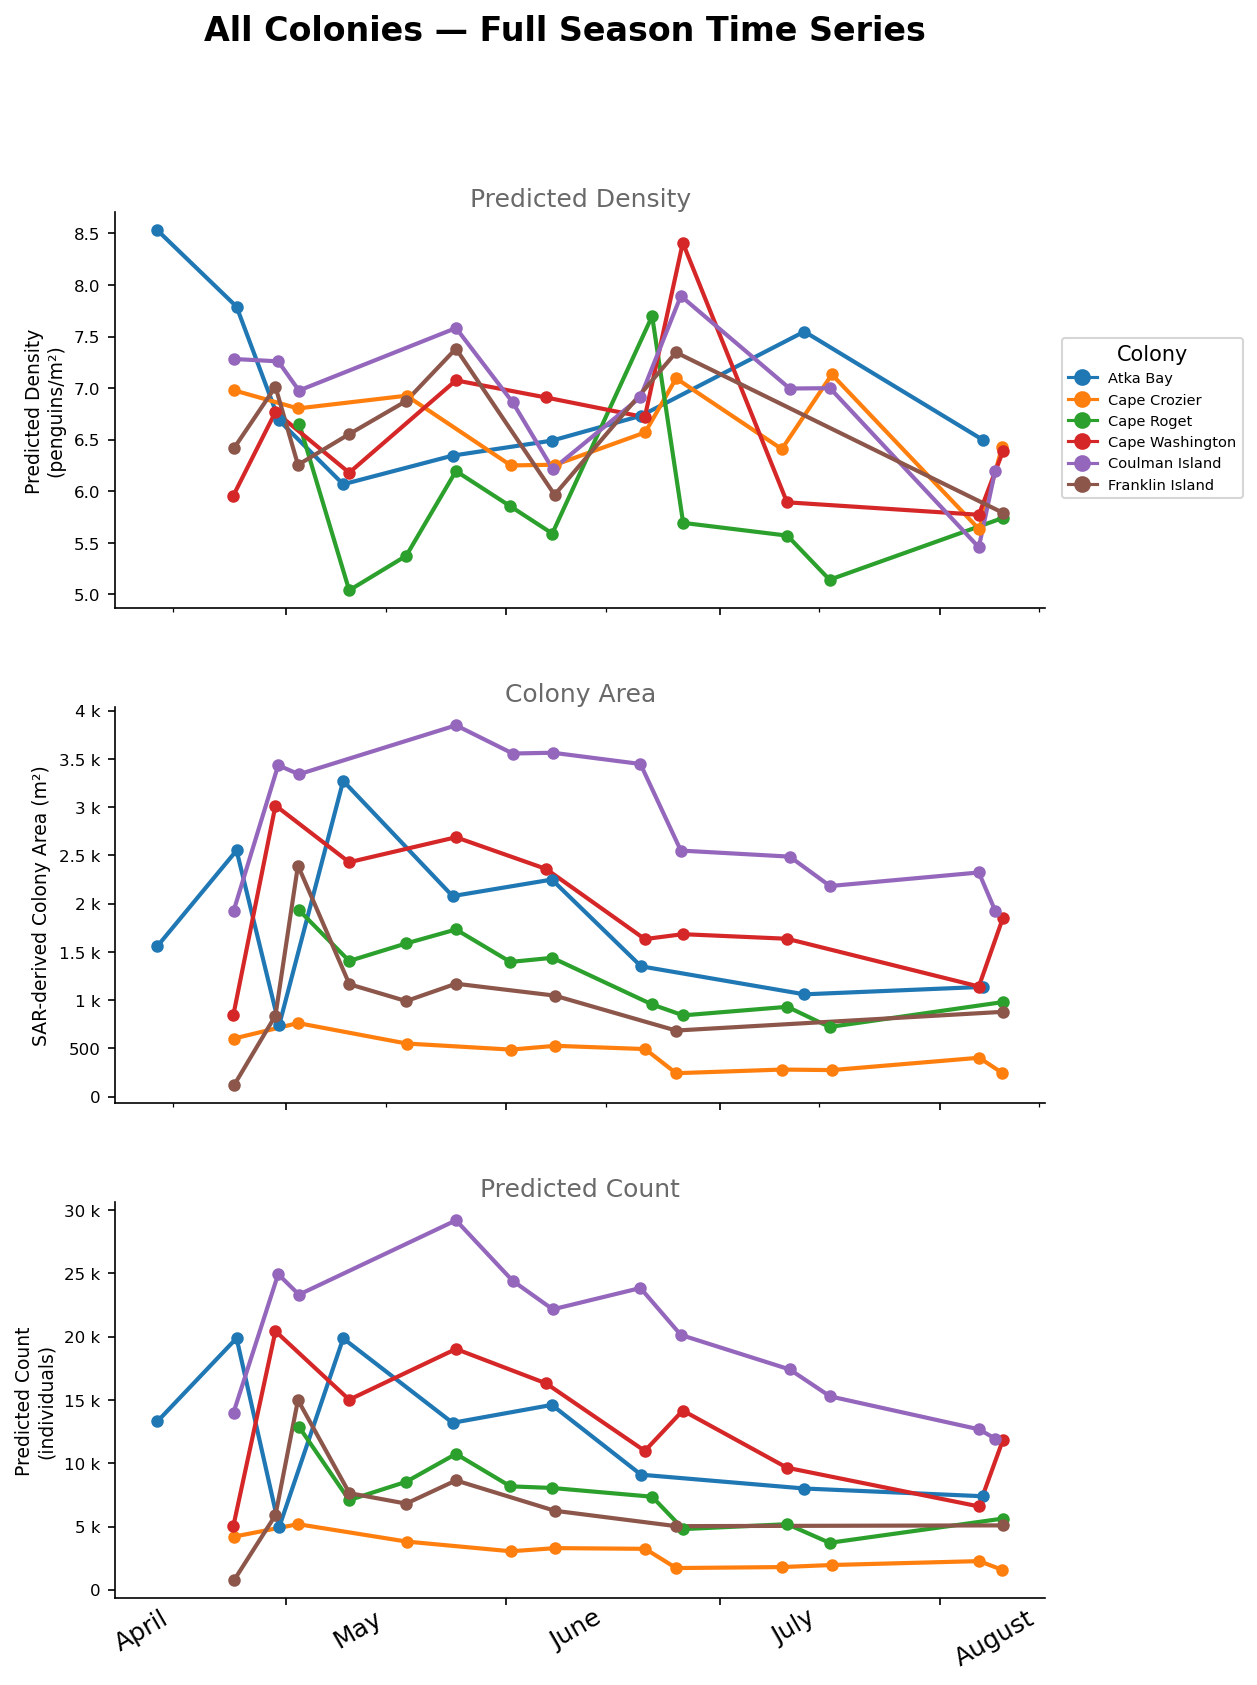

In [ ]:
# Wow it worked 
#Now i wantto recreate Alex's plot to see if it matchs
import os

# ── All colonies in one figure, coloured by colony ────────────────────────────
# Three panels: area, density, count
# All colonies overlaid, coloured by colony name

# Generate colour per colony
colonies_all = sorted(dfMLR["colony"].unique())
cmap = plt.cm.get_cmap("tab20", len(colonies_all))
#colony_colors = {colony: cmap(i) for i, colony in enumerate(colonies_all)}

# ── Manual colony colours ──────────────────────────────────────────────────────
#To match Alex Winterl example
colony_colors = {
    "Atka Bay":        "#1f77b4",  # blue
    "Cape Roget":      "#2ca02c",  # green
    "Coulman Island":  "#9467bd",  # purple
    "Cape Crozier":    "#ff7f0e",  # orange
    "Cape Washington": "#d62728",  # red
    "Franklin Island": "#8c564b",  # brown
}

colonies_all = sorted(colony_colors.keys())
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

for colony in colonies_all:
    df = dfMLR[dfMLR["colony"] == colony].copy()
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values("datetime")

    if len(df) == 0:
        continue

    color = colony_colors[colony]

    # ── Panel 1: Area ──────────────────────────────────────────────────────────
    ax = axes[1]
    df_a = df[df["area_m2"].notna() & (df["area_m2"] != 0)]
    ax.scatter(df_a["datetime"], df_a["area_m2"],
               s=25, color=color, zorder=3, alpha=1)
    ax.plot(df_a["datetime"], df_a["area_m2"],
            color=color, linewidth=2.0, alpha=1, label=colony)

    # ── Panel 2: Density ───────────────────────────────────────────────────────
    ax = axes[0]
    df_d = df[df["area_m2"].notna() & (df["area_m2"] != 0)]
    if len(df_d) > 0:
        ax.plot(df_d["datetime"], df_d["rho_pred"],
                color=color, linewidth=2.0, alpha=1)
        ax.scatter(df_d["datetime"], df_d["rho_pred"],
                   s=25, color=color, zorder=3, alpha=1)

    # ── Panel 3: Count ─────────────────────────────────────────────────────────
    ax = axes[2]
    df_c = df[df["count_pred"].notna() & (df["count_pred"] != 0)]
    if len(df_c) > 0:
        ax.plot(df_c["datetime"], df_c["count_pred"],
                color=color, linewidth=2.0, alpha=1)
        ax.scatter(df_c["datetime"], df_c["count_pred"],
                   s=25, color=color, zorder=3, alpha=1)

# ── Peak huddle window shading ─────────────────────────────────────────────────
#for yr in dfArea["datetime"].apply(pd.Timestamp).dt.year.unique():
#    axes[2].axvspan(
#        pd.Timestamp(f"{yr}-06-25"),
#        pd.Timestamp(f"{yr}-07-31"),
#        alpha=0.08, color="purple",
#        label="Peak huddle window" if yr == dfArea["datetime"].apply(
#            pd.Timestamp).dt.year.unique()[0] else None
#    )

# ── Formatting ─────────────────────────────────────────────────────────────────
axes[1].set_ylabel("SAR-derived Colony Area (m²)")
axes[0].set_ylabel("Predicted Density\n(penguins/m²)")
axes[2].set_ylabel("Predicted Count\n(individuals)")

axes[1].yaxis.set_major_formatter(mtick.EngFormatter(unit=""))
axes[2].yaxis.set_major_formatter(mtick.EngFormatter(unit=""))

for ax, subtitle in zip(axes, ["Predicted Density", "Colony Area", "Predicted Count"]):
    ax.set_title(subtitle, fontsize=12, color="dimgrey", pad=3)
    ax.tick_params(labelsize=8)
    ax.yaxis.label.set_size(9)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# ── X axis formatting ──────────────────────────────────────────────────────────
axes[2].xaxis.set_major_locator(mdates.MonthLocator())
axes[2].xaxis.set_major_formatter(mtick.NullFormatter())
axes[2].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=15))
axes[2].xaxis.set_minor_formatter(mdates.DateFormatter("%B"))
for label in axes[2].xaxis.get_minorticklabels():
    label.set_rotation(30)
    label.set_ha("right")
    label.set_fontsize(12)
axes[2].tick_params(axis="x", which="minor", length=0)

# ── Legend ─────────────────────────────────────────────────────────────────────
# Place legend outside the plot to avoid obscuring data
legend_handles = [
    plt.Line2D([0], [0], color=colony_colors[c], linewidth=1.5,
               marker="o", markersize=7, label=c)
    for c in colonies_all
]
axes[2].legend(handles=legend_handles,
               loc="upper left",
               bbox_to_anchor=(1.01, 3.2),
               fontsize=7, frameon=True,
               ncol=1, title="Colony")

fig.suptitle("All Colonies — Full Season Time Series",
             fontsize=16, fontweight="bold", y=0.99)

plt.tight_layout(rect=[0, 0, 0.88, 0.97])
plt.subplots_adjust(hspace=0.25)

plt.savefig(os.path.join(INPUTPATH, "all_colonies_timeseries_MLR_simplev5.png"),
            bbox_inches="tight", dpi=150)
plt.show()

# Making the values opposite has made the figure match his

I believe this may indicate there was a typo in the publication and the coefficients are meant to be opposite. I have not yet confirmed this, but as that change made the data match the analysis he ran for Michelle, I think that might be the case. 


I will move forward with this as the correction. 

In the context of the equation, I believe this makes ecologically sense:  
That is that density **increases** with higher winds, lower temperatures and lower solar radiation. 

The way the rho_pred equation is structured, along with the published coefficients indicate that the original model found the opposite - that huddles were closer together when it was warmer, which we know is not true. 

I think there was a typographical error in the supplementary material and we will move forward with this. 


# 2025 SAR Data 

dfRFD

In [ ]:
#Only relevant for Our 2025 data:
#For the Sabrina records we had to capture 2 images to get all subgroups of the colonies
#This code combined the observations that were captured on the same date


# Inspect Sabrina records
sabrina = dfRFD[dfRFD["colony_name"] == "Sabrina"].sort_values("ts")
print(f"Sabrina records: {len(sabrina)}")
print(sabrina[["colony_name", "ts", "DOY", "area_m2"]].to_string())

# Combine same-day Sabrina records by summing area
# Records are 1 minute apart — two SAR swaths of the same dispersed colony
sabrina_combined = dfRFD[dfRFD["colony_name"] == "Sabrina"].copy()
sabrina_combined["ts_date"] = pd.to_datetime(sabrina_combined["ts"]).dt.date

# Build agg dict dynamically using only columns that exist
agg_dict = {
    "colony_name": ("colony_name", "first"),
    "ts":          ("ts",          "first"),
    "DOY":         ("DOY",         "first"),
    "area_m2":     ("area_m2",     "sum"),
}

# Add weather columns only if they exist
for col in ["temp_airK", "met_ff10", "met_rad", "met_humc"]:
    if col in sabrina_combined.columns:
        agg_dict[col] = (col, "first")

# Add any other columns that exist
for col in ["lat", "lon", "season", "month", "day"]:
    if col in sabrina_combined.columns:
        agg_dict[col] = (col, "first")

sabrina_grouped = (sabrina_combined
    .groupby("ts_date")
    .agg(**agg_dict)
    .reset_index(drop=True)
)

# Drop rows where area_m2 is NaN or zero after summing
# (both swaths had NaN area — no usable observation)
sabrina_grouped = sabrina_grouped[sabrina_grouped["area_m2"] > 0].copy()

# Replace Sabrina rows in dfArea
dfRFD = dfRFD[dfRFD["colony_name"] != "Sabrina"].copy()
dfRFD = pd.concat([dfRFD, sabrina_grouped], ignore_index=True)
dfRFD = dfRFD.sort_values(["colony_name", "ts"]).reset_index(drop=True)

print(f"\nCombined Sabrina records: {len(dfRFD[dfRFD['colony_name'] == 'Sabrina'])}")
print(dfRFD[dfRFD["colony_name"] == "Sabrina"][["ts", "DOY", "area_m2"]].to_string())

In [ ]:
#Ok now we need to do the same thing but for our 2025 data 
#Weather data from Michelle's 2024 data
T = dfRFD["temp_airK"].values
W = dfRFD["met_ff10"].values
R = dfRFD["met_rad"].values
H = dfRFD["met_humc"].values


rho_pred = rho_max/(1 + np.exp( cT*T + cW*W + cH*H + cR*R - Tc ))


area_m2 = dfRFD["area_m2"].values

count_pred = rho_pred * area_m2

# Add to dataframe
dfRFD["rho_pred"] = rho_pred
dfRFD["count_pred"] = count_pred

# Export
#dfRFD.to_csv(os.path.join(INPUTPATH, "dfRFD_with_predictions_v2.csv"), index=False)
print(f"Exported {len(dfMLR)} rows to dfRFD_with_predictions.csv")
print(dfRFD[["colony_name", "date", "rho_pred", "count_pred"]].dropna().head(10).round(2))


#This way propagates uncertainty: 

# Simple uncertainty — propagate SDs as ± 1 standard deviation
exponent_lower = (cT - sd_T) * T + (cW + sd_W) * W + (cR - sd_R) * R + (cH + sd_H) * H - (Tc - sd_Tc) #these were labeled backwards - have corrected here and in the csvs
exponent_upper = (cT + sd_T) * T + (cW - sd_W) * W + (cR + sd_R) * R + (cH - sd_H) * H - (Tc + sd_Tc) #these were labeled backwards - have corrected here and in the csvs

dfRFD["rho_lower"] = rho_max / (1 + np.exp(exponent_lower))
dfRFD["rho_upper"] = rho_max / (1 + np.exp(exponent_upper))

print(dfRFD.columns.tolist())
# Count predictions
dfRFD["count_pred"]  = dfRFD["rho_pred"]  * dfRFD["area_m2"]
dfRFD["count_lower"] = dfRFD["rho_lower"] * dfRFD["area_m2"]
dfRFD["count_upper"] = dfRFD["rho_upper"] * dfRFD["area_m2"]


# Apparent temperature — point estimate
dfRFD["Ta_C"] = T + (cW * W + cR * R + cH * H) / cT - 273.15


print(dfRFD[["colony_name", "date", "rho_pred", "rho_lower", "rho_upper", 
             "count_pred", "count_lower",  "count_upper", "Ta_C"]].dropna().head(10).round(3))


dfRFD.to_csv(os.path.join(INPUTPATH, "Final results/dfRFD_with_predictions_final.csv"), index=False)



Exported 64 rows to dfRFD_with_predictions.csv
   colony_name       date  rho_pred  count_pred
0       Amanda 2025-04-24      6.06    17489.40
1       Amanda 2025-05-24      5.54     5991.18
2       Amanda 2025-06-30      5.98     8947.48
3       Amanda 2025-07-22      6.09     9616.65
4       Amanda 2025-08-20      6.29    15558.12
6     Amundsen 2025-05-25      5.47      249.45
7     Amundsen 2025-06-30      5.52      336.53
8     Amundsen 2025-07-19      5.75      246.11
11      Astrid 2025-04-25      7.99    16672.69
12      Astrid 2025-06-26      5.56     5988.50
['colony_name', 'site_id', 'group', 'image_id', 'date', 'month', 'day', 'year', 'DOY', 'lat', 'lon', 'avg_size', 'area_m2', 'observation(1-5)', 'grazing', 'incidence', 'azimuth', 'resolution', 'looks', 'orbit_state', 'polarization', 'slant_range', 'surface_type', 'obs', 'date_time', 'time', 'time_UTC', 'date_UTC', 'ts', 'met_ff10', 'temp_airK', 'met_humc', 'met_rad', 'd2m', 'rh_water', 'rh_ice', 'rho_pred', 'count_pred', 

/tmp/ipykernel_1920707/3459048598.py:25: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(dfRFD[["colony_name", "date", "rho_pred", "count_pred"]].dropna().head(10).round(2))
/tmp/ipykernel_1920707/3459048598.py:52: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  "count_pred", "count_lower",  "count_upper", "Ta_C"]].dropna().head(10).round(3))


/tmp/ipykernel_1920707/1378261837.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(colonies_all))
/tmp/ipykernel_1920707/1378261837.py:117: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.88, 0.97])


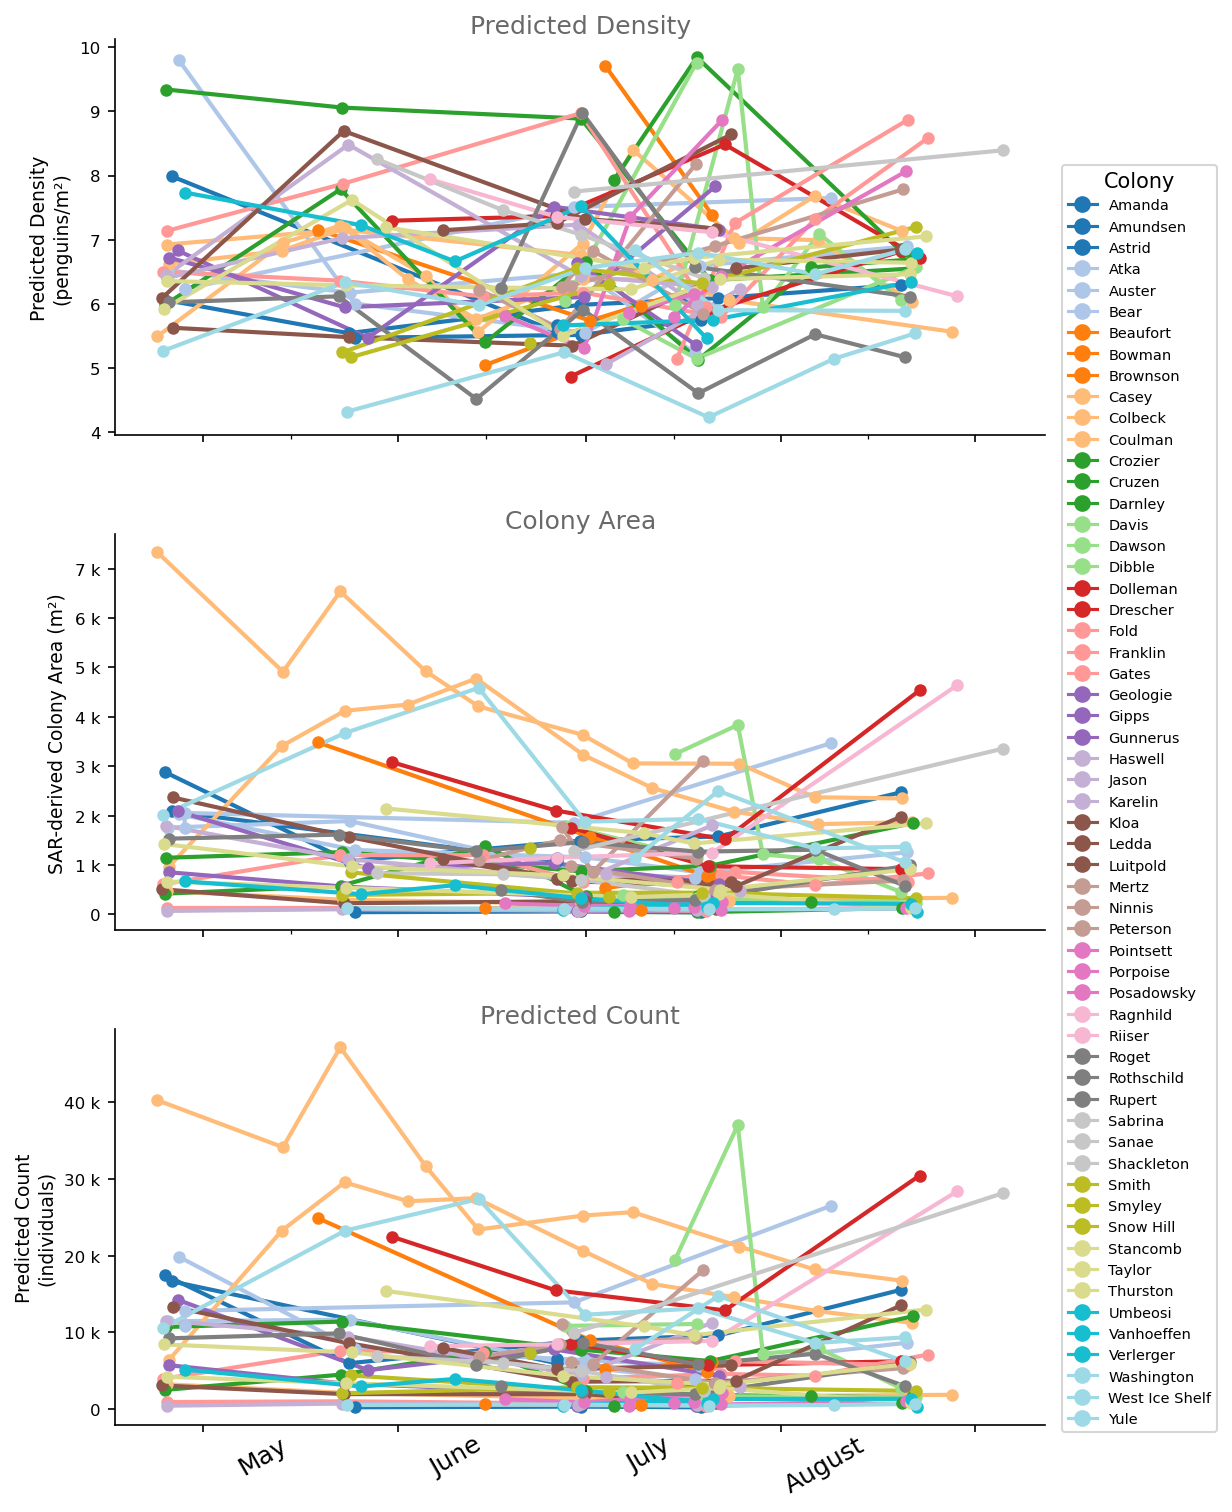

In [ ]:
#Now we'll remake the figure 


import os

# ── All colonies in one figure, coloured by colony ────────────────────────────
# Three panels: area, density, count
# All colonies overlaid, coloured by colony name

# Generate colour per colony
colonies_all = sorted(dfRFD["colony_name"].unique())
cmap = plt.cm.get_cmap("tab20", len(colonies_all))
colony_colors = {colony: cmap(i) for i, colony in enumerate(colonies_all)}

colonies_all = sorted(colony_colors.keys())
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

for colony in colonies_all:
    df = dfRFD[dfRFD["colony_name"] == colony].copy()
    df["date_time"] = pd.to_datetime(df["date_time"])
    df = df.sort_values("date_time")

    if len(df) == 0:
        continue

    color = colony_colors[colony]

    # ── Panel 1: Area ──────────────────────────────────────────────────────────
    ax = axes[1]
    df_a = df[df["area_m2"].notna() & (df["area_m2"] != 0)]
    ax.scatter(df_a["date_time"], df_a["area_m2"],
               s=25, color=color, zorder=3, alpha=1)
    ax.plot(df_a["date_time"], df_a["area_m2"],
            color=color, linewidth=2.0, alpha=1, label=colony)

    # ── Panel 2: Density ───────────────────────────────────────────────────────
    ax = axes[0]
    df_d = df[df["area_m2"].notna() & (df["area_m2"] != 0)]
    if len(df_d) > 0:
        ax.plot(df_d["date_time"], df_d["rho_pred"],
                color=color, linewidth=2.0, alpha=1)
        ax.scatter(df_d["date_time"], df_d["rho_pred"],
                   s=25, color=color, zorder=3, alpha=1)

    # ── Panel 3: Count ─────────────────────────────────────────────────────────
    ax = axes[2]
    df_c = df[df["count_pred"].notna() & (df["count_pred"] != 0)]
    if len(df_c) > 0:
        ax.plot(df_c["date_time"], df_c["count_pred"],
                color=color, linewidth=2.0, alpha=1)
        ax.scatter(df_c["date_time"], df_c["count_pred"],
                   s=25, color=color, zorder=3, alpha=1)


# ── Formatting ─────────────────────────────────────────────────────────────────
axes[1].set_ylabel("SAR-derived Colony Area (m²)")
axes[0].set_ylabel("Predicted Density\n(penguins/m²)")
axes[2].set_ylabel("Predicted Count\n(individuals)")

axes[1].yaxis.set_major_formatter(mtick.EngFormatter(unit=""))
axes[2].yaxis.set_major_formatter(mtick.EngFormatter(unit=""))

for ax, subtitle in zip(axes, ["Predicted Density", "Colony Area", "Predicted Count"]):
    ax.set_title(subtitle, fontsize=12, color="dimgrey", pad=3)
    ax.tick_params(labelsize=8)
    ax.yaxis.label.set_size(9)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# ── X axis formatting ──────────────────────────────────────────────────────────
axes[2].xaxis.set_major_locator(mdates.MonthLocator())
axes[2].xaxis.set_major_formatter(mtick.NullFormatter())
axes[2].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=15))
axes[2].xaxis.set_minor_formatter(mdates.DateFormatter("%B"))
for label in axes[2].xaxis.get_minorticklabels():
    label.set_rotation(30)
    label.set_ha("right")
    label.set_fontsize(12)
axes[2].tick_params(axis="x", which="minor", length=0)

# ── Legend ─────────────────────────────────────────────────────────────────────
# Place legend outside the plot to avoid obscuring data
legend_handles = [
    plt.Line2D([0], [0], color=colony_colors[c], linewidth=1.5,
               marker="o", markersize=7, label=c)
    for c in colonies_all
]
axes[2].legend(handles=legend_handles,
               loc="upper left",
               bbox_to_anchor=(1.01, 3.2),
               fontsize=7, frameon=True,
               ncol=1, title="Colony")


plt.tight_layout(rect=[0, 0, 0.88, 0.97])
plt.subplots_adjust(hspace=0.25)

plt.savefig(os.path.join(INPUTPATH, "Final results/all_colonies_timeseries_RFD_simple_final.png"),
            bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
# ── One figure per colony ─────────────────────────────────────────────────────
output_folder = os.path.join(INPUTPATH, "Final results/colony_timeseries")
os.makedirs(output_folder, exist_ok=True)

colonies_all = sorted(dfRFD["colony_name"].unique())

for colony in colonies_all:
    df = dfRFD[dfRFD["colony_name"] == colony].copy()
    df["date_time"] = pd.to_datetime(df["date_time"])
    df = df.sort_values("date_time")

    if len(df) == 0:
        continue

    color = "#0072B2"

    fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

    # ── Panel 1: Density ───────────────────────────────────────────────────────
    ax = axes[0]
    df_d = df[df["rho_pred"].notna() & (df["area_m2"] != 0)]
    if len(df_d) > 0:
        ax.plot(df_d["date_time"], df_d["rho_pred"],
                color=color, linewidth=1.8, alpha=1)
        ax.scatter(df_d["date_time"], df_d["rho_pred"],
                   s=30, color=color, zorder=3)
        # Uncertainty band
        if "rho_lower" in df_d.columns and "rho_upper" in df_d.columns:
            ax.fill_between(df_d["date_time"],
                            df_d["rho_lower"], df_d["rho_upper"],
                            color=color, alpha=0.2)

    # ── Panel 2: Area ──────────────────────────────────────────────────────────
    ax = axes[1]
    df_a = df[df["area_m2"].notna() & (df["area_m2"] != 0)]
    if len(df_a) > 0:
        ax.plot(df_a["date_time"], df_a["area_m2"],
                color=color, linewidth=1.8, alpha=1)
        ax.scatter(df_a["date_time"], df_a["area_m2"],
                   s=30, color=color, zorder=3)

        # avg_size reference line if available
        avg = df_a["avg_size"].dropna()
        if len(avg) > 0:
            ax.axhline(avg.iloc[0], color="gray", linewidth=1.0,
                       linestyle="--", alpha=0.7,
                       label=f"Spring baseline (avg_size = {avg.iloc[0]:,.0f} abundance index)")
            ax.legend(frameon=False, fontsize=7)

    # ── Panel 3: Count ─────────────────────────────────────────────────────────
    ax = axes[2]
    df_c = df[df["count_pred"].notna() & (df["count_pred"] != 0)]
    if len(df_c) > 0:
        ax.plot(df_c["date_time"], df_c["count_pred"],
                color=color, linewidth=1.8, alpha=1)
        ax.scatter(df_c["date_time"], df_c["count_pred"],
                   s=30, color=color, zorder=3)
        if "count_lower" in df_c.columns and "count_upper" in df_c.columns:
            err_low  = np.maximum(df_c["count_pred"] - df_c["count_lower"], 0)
            err_high = np.maximum(df_c["count_upper"] - df_c["count_pred"], 0)
            ax.fill_between(df_c["date_time"],
                            df_c["count_pred"] - err_low,
                            df_c["count_pred"] + err_high,
                            color=color, alpha=0.2)

    # ── Formatting ─────────────────────────────────────────────────────────────
    axes[0].set_ylabel("Predicted Density\n(penguins/m²)", fontsize=9)
    axes[1].set_ylabel("Colony Area (m²)", fontsize=9)
    axes[2].set_ylabel("Predicted Count\n(individuals)", fontsize=9)

    axes[1].yaxis.set_major_formatter(mtick.EngFormatter(unit=""))
    axes[2].yaxis.set_major_formatter(mtick.EngFormatter(unit=""))

    for ax, subtitle in zip(axes, ["Predicted Density", "Colony Area", "Predicted Count"]):
        ax.set_title(subtitle, fontsize=10, color="dimgrey", pad=3)
        ax.tick_params(labelsize=8)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    # Month labels on x axis
    axes[2].xaxis.set_major_locator(mdates.MonthLocator())
    axes[2].xaxis.set_major_formatter(mtick.NullFormatter())
    axes[2].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=15))
    axes[2].xaxis.set_minor_formatter(mdates.DateFormatter("%B"))
    for label in axes[2].xaxis.get_minorticklabels():
        label.set_rotation(30)
        label.set_ha("right")
        label.set_fontsize(9)
    axes[2].tick_params(axis="x", which="minor", length=0)

    fig.suptitle(colony, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)

    # Save — colony name for filename
    safe_name = colony.replace(" ", "_").replace("/", "-")
    filepath = os.path.join(output_folder, f"{safe_name}_timeseries.png")
    plt.savefig(filepath, bbox_inches="tight", dpi=150)
    plt.close()
    print(f"Saved: {safe_name}_timeseries.png")

print(f"\nDone — {len(colonies_all)} figures saved to: {output_folder}")

2025 chick counts:
    colony  count_total       date   DOY
    Amanda      10387.0 2025-11-28 332.0
    Astrid       6258.0 2025-10-20 293.0
   Coulman       6686.0 2025-12-06 340.0
   Crozier       2782.0 2025-11-22 326.0
   Lazarev        800.0 2025-12-17 351.0
     Roget       7736.0 2025-11-13 317.0
    Taylor       1987.0 2025-11-21 325.0
Washington      14297.0 2025-11-09 313.0

Comparison: chick count vs SAR-derived breeding pairs (June & July median):
Colony           BP_Jun  Ratio_Jun   BP_Jul  Ratio_Jul   Chicks_obs                 Note
------------------------------------------------------------------------------------------
Amanda             8947       1.16     9617       1.08        10387         ⚠ high ratio
Astrid             6253       1.00        —        —         6258        ⚠ no July obs
Coulman           27109       0.25    15468       0.43         6686         ✓ consistent
Crozier            4960       0.56     1876       1.48         2782         ⚠ high ratio
L

# Now we want to use the same density model on the VHR Optical imagery and see what happens 

That data is stored in dfVHR dataframe as above 



In [133]:
dfVHR = pd.read_excel(
    os.path.join(INPUTPATH, "VHR_RossSea2025_area-data_v1.xlsx")
)

print(dfVHR.head())


     colony                                     image_id       lat  \
0  Coulman   25SEP25001027-P3DS-050498012010_01_P001.TIF -73.34830   
1  Coulman   25SEP25001027-P3DS-050498012010_01_P001.TIF -73.34830   
2  Coulman   25SEP25001027-P3DS-050498012010_01_P001.TIF -73.34830   
3  Franklin  25OCT24235922-P3DS-050498009010_01_P001.TIF -76.17738   
4  Colbeck   25SEP29221944-P3DS-050498011010_01_P001.TIF -77.15140   

          lon       date  time_UTC       area_m2  image_qual  \
0  169.624200 2025-09-25  00:10:27   5566.763985           3   
1  169.624200 2025-09-25  00:10:27  11426.245350           3   
2  169.624200 2025-09-25  00:10:27  16993.009330           3   
3  168.394475 2025-10-24  23:59:22   2934.939757           3   
4 -157.584100 2025-09-29  22:19:44  26896.498480           3   

                                    notes    method  ... month day  doy  \
0                 birds on top of iceberg  Set Null  ...     9  25  268   
1                        birds at colony   S

In [ ]:
T = dfVHR["temp_airK"].values
W = dfVHR["met_ff10"].values
R = dfVHR["met_rad"].values
H = dfVHR["met_humc"].values



rho_pred = rho_max/(1 + np.exp( cT*T + cW*W + cH*H + cR*R - Tc ))


area_m2 = dfVHR["area_m2"].values

count_pred = rho_pred * area_m2

# Add to dataframe
dfVHR["rho_pred"] = rho_pred
dfVHR["count_pred"] = count_pred

# Export
#dfVHR.to_csv(os.path.join(INPUTPATH, "dfVHR_with_predictions_v2.csv"), index=False)
print(f"Exported {len(dfVHR)} rows to dfVHR_with_predictions.csv")
print(dfVHR[["colony", "date", "rho_pred", "count_pred"]].dropna().head(10).round(2))


#This way propagates uncertainty: 

# Simple uncertainty — propagate SDs as ± 1 standard deviation
exponent_lower = (cT - sd_T) * T + (cW + sd_W) * W + (cR - sd_R) * R + (cH + sd_H) * H - (Tc - sd_Tc) 
exponent_upper = (cT + sd_T) * T + (cW - sd_W) * W + (cR + sd_R) * R + (cH - sd_H) * H - (Tc + sd_Tc) 
dfVHR["rho_lower"] = rho_max / (1 + np.exp(exponent_lower))
dfVHR["rho_upper"] = rho_max / (1 + np.exp(exponent_upper))

print(dfVHR.columns.tolist())
# Count predictions
dfVHR["count_pred"]  = dfVHR["rho_pred"]  * dfVHR["area_m2"]
dfVHR["count_lower"] = dfVHR["rho_lower"] * dfVHR["area_m2"]
dfVHR["count_upper"] = dfVHR["rho_upper"] * dfVHR["area_m2"]


# Apparent temperature — point estimate
dfVHR["Ta_C"] = T + (cW * W + cR * R + cH * H) / cT - 273.15



print(dfVHR[["colony", "date", "rho_pred", "rho_lower", "rho_upper", 
             "count_pred", "count_lower",  "count_upper", "Ta_C"]].dropna().head(10).round(3))

dfVHR.to_csv(os.path.join(INPUTPATH, "Final results/dfVHR_with_predictions_final.csv"), index=False)



Exported 13 rows to dfVHR_with_predictions.csv
        colony       date  rho_pred  count_pred
0     Coulman  2025-09-25      5.23    29088.16
1     Coulman  2025-09-25      5.23    59705.87
2     Coulman  2025-09-25      5.23    88794.04
3     Franklin 2025-10-24      5.06    14857.13
4     Colbeck  2025-09-29      5.99   160987.53
5    Beaufort  2025-10-03      4.30     1198.41
6       Roget  2025-10-22      5.62    21047.74
7  Washington  2025-11-01      5.06    31907.05
8      Crozier 2025-10-10      6.06    15571.72
9     Coulman  2024-10-12      4.50    68625.72
['colony', 'image_id', 'lat', 'lon', 'date', 'time_UTC', 'area_m2', 'image_qual', 'notes', 'method', 'date_time', 'date_utc', 'time_utc', 'ts', 'year', 'month', 'day', 'doy', 'met_ff10', 'temp_airK', 'd2m', 'met_humc', 'rh_water', 'rh_ice', 'met_rad', 'rho_pred', 'count_pred', 'rho_lower', 'rho_upper', 'count_lower', 'count_upper', 'Ta_C']
        colony       date  rho_pred  rho_lower  rho_upper  count_pred  \
0     Coul

/tmp/ipykernel_1920707/1716694356.py:22: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(dfVHR[["colony", "date", "rho_pred", "count_pred"]].dropna().head(10).round(2))
/tmp/ipykernel_1920707/1716694356.py:49: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  "count_pred", "count_lower",  "count_upper", "Ta_C"]].dropna().head(10).round(3))
